In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, SVD
from surprise.model_selection import cross_validate, train_test_split, GridSearchCV
from surprise import accuracy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load data
ratings = pd.read_csv("ml-1m/ratings.dat", sep="::", engine="python",
                      names=["user_id", "movie_id", "rating", "timestamp"])
movies = pd.read_csv("ml-1m/movies.dat", sep="::", engine="python",
                     names=["movie_id", "title", "genres"], encoding="latin-1")

ratings.drop(columns=["timestamp"], inplace=True)

print(f"Ratings: {len(ratings):,}")
print(f"Movies : {len(movies):,}")
print("Data loaded successfully.")

ModuleNotFoundError: No module named 'pandas'

In [21]:
# Surprise reader & dataset
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(ratings[["user_id", "movie_id", "rating"]], reader)

# 80/20 split — same as Phase 2 for fair comparison
trainset, testset = train_test_split(data, test_size=0.20, random_state=42)

print(f"Trainset: {trainset.n_ratings:,} ratings")
print(f"Testset : {len(testset):,} ratings")
print("Split complete.")

Trainset: 800,167 ratings
Testset : 200,042 ratings
Split complete.


In [22]:
# MODEL 1: SVD (Matrix Factorization)
print("=== MODEL 1: SVD ===")

svd_model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)

svd_predictions = svd_model.test(testset)

svd_rmse = accuracy.rmse(svd_predictions, verbose=False)
svd_mae  = accuracy.mae(svd_predictions,  verbose=False)

print(f"RMSE : {svd_rmse:.4f}")
print(f"MAE  : {svd_mae:.4f}")
print(f"Improvement over baseline RMSE: {0.9604 - svd_rmse:.4f}")

=== MODEL 1: SVD ===
RMSE : 0.8729
MAE  : 0.6845
Improvement over baseline RMSE: 0.0875


In [23]:
# 5-fold CV to confirm SVD stability
print("=== SVD 5-FOLD CROSS VALIDATION ===")

cv_results = cross_validate(
    SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42),
    data,
    measures=["RMSE", "MAE"],
    cv=5,
    verbose=True
)

print(f"\nMean RMSE : {np.mean(cv_results['test_rmse']):.4f}")
print(f"Mean MAE  : {np.mean(cv_results['test_mae']):.4f}")
print(f"Std  RMSE : {np.std(cv_results['test_rmse']):.4f}")

=== SVD 5-FOLD CROSS VALIDATION ===
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8745  0.8733  0.8715  0.8769  0.8746  0.8742  0.0018  
MAE (testset)     0.6867  0.6865  0.6842  0.6890  0.6858  0.6864  0.0015  
Fit time          6.88    5.76    6.74    5.82    6.40    6.32    0.46    
Test time         0.59    1.16    0.56    1.20    0.58    0.82    0.30    

Mean RMSE : 0.8742
Mean MAE  : 0.6864
Std  RMSE : 0.0018


In [24]:
# MODEL 2: HYBRID (SVD + CBF) — optimized
print("=== MODEL 2: HYBRID ===")

movies["genres_clean"] = movies["genres"].str.replace("|", " ", regex=False)
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies["genres_clean"])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

movie_ids = movies["movie_id"].tolist()
movie_idx = {mid: i for i, mid in enumerate(movie_ids)}

user_ratings_dict = ratings.groupby("user_id").apply(
    lambda x: list(zip(x["movie_id"], x["rating"]))
).to_dict()

def cbf_score_fast(user_id, movie_id):
    if movie_id not in movie_idx:
        return 3.5
    user_hist = user_ratings_dict.get(user_id, [])
    if not user_hist:
        return 3.5
    idx = movie_idx[movie_id]
    scores = []
    for mid, r in user_hist[:50]:
        if mid in movie_idx:
            sim = cosine_sim[idx][movie_idx[mid]]
            scores.append((sim, r))
    if not scores:
        return 3.5
    scores.sort(reverse=True)
    top = scores[:10]
    total_sim = sum(s for s, _ in top)
    return sum(s * r for s, r in top) / total_sim if total_sim > 0 else 3.5

def get_alpha(user_id):
    n = len(user_ratings_dict.get(user_id, []))
    if n < 5:  return 0.0
    if n < 20: return 0.3
    if n < 50: return 0.7
    return 1.0

print("Computing hybrid predictions...")
hybrid_predictions = []
for uid, iid, true_r, est, _ in svd_predictions:
    alpha = get_alpha(uid)
    cbf   = cbf_score_fast(uid, iid)
    hybrid_est = alpha * est + (1 - alpha) * cbf
    hybrid_predictions.append((uid, iid, true_r, hybrid_est))

hybrid_rmse = np.sqrt(np.mean([(t - p) ** 2 for _, _, t, p in hybrid_predictions]))
hybrid_mae  = np.mean([abs(t - p) for _, _, t, p in hybrid_predictions])

print(f"RMSE : {hybrid_rmse:.4f}")
print(f"MAE  : {hybrid_mae:.4f}")
print(f"Improvement over baseline : {0.9604 - hybrid_rmse:.4f}")
print(f"Improvement over SVD      : {svd_rmse - hybrid_rmse:.4f}")

=== MODEL 2: HYBRID ===
Computing hybrid predictions...
RMSE : 0.8696
MAE  : 0.6822
Improvement over baseline : 0.0908
Improvement over SVD      : 0.0033


=== FINAL MODEL COMPARISON ===
Model                    RMSE      MAE  vs Baseline
----------------------------------------------------
Baseline (User-CF)     0.9604   0.7642            —
SVD                    0.8729   0.6845     +0.0875
Hybrid (SVD+CBF)       0.8696   0.6822     +0.0908


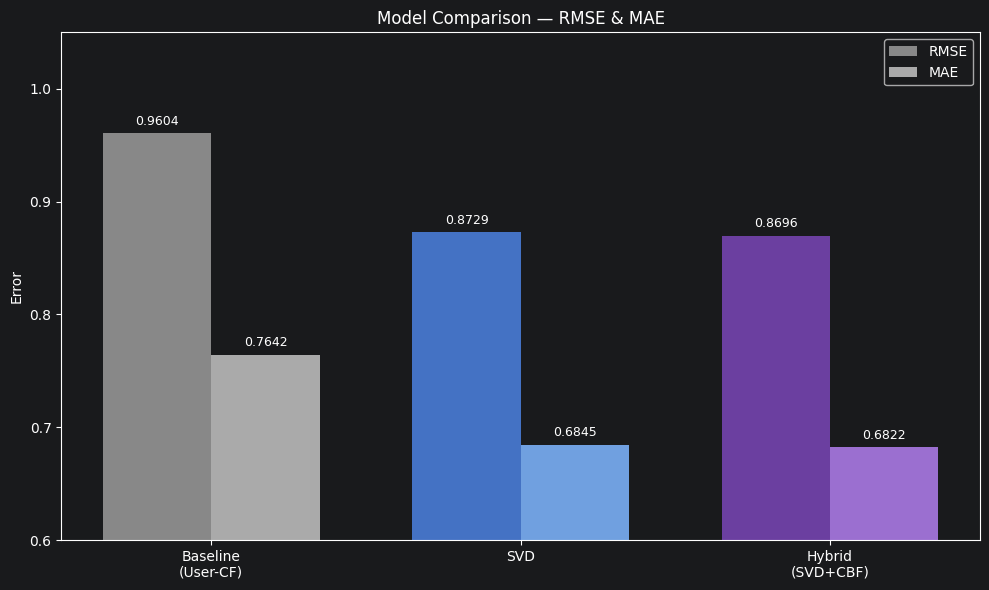

Plot saved → model_comparison.png


In [25]:
# FINAL COMPARISON
print("=== FINAL MODEL COMPARISON ===")
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8} {'vs Baseline':>12}")
print("-" * 52)
print(f"{'Baseline (User-CF)':<20} {0.9604:>8.4f} {0.7642:>8.4f} {'—':>12}")
print(f"{'SVD':<20} {svd_rmse:>8.4f} {svd_mae:>8.4f} {0.9604-svd_rmse:>+11.4f}")
print(f"{'Hybrid (SVD+CBF)':<20} {hybrid_rmse:>8.4f} {hybrid_mae:>8.4f} {0.9604-hybrid_rmse:>+11.4f}")

# Plot
models   = ["Baseline\n(User-CF)", "SVD", "Hybrid\n(SVD+CBF)"]
rmse_vals = [0.9604, svd_rmse, hybrid_rmse]
mae_vals  = [0.7642, svd_mae,  hybrid_mae]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rmse_vals, width, label="RMSE", color=["#888888", "#4472C4", "#6B3FA0"])
bars2 = ax.bar(x + width/2, mae_vals,  width, label="MAE",  color=["#AAAAAA", "#70A0E0", "#9B6FD0"])

ax.set_ylabel("Error")
ax.set_title("Model Comparison — RMSE & MAE")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0.6, 1.05)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Plot saved → model_comparison.png")

In [26]:
# COLD START SIMULATION
print("=== COLD START SIMULATION ===")

# Simulate cold start: users with fewer than 25 ratings
cold_users_sim = set(user_rating_counts[user_rating_counts < 25].index)
cold_testset_sim = [(uid, iid, r) for uid, iid, r in testset if uid in cold_users_sim]

print(f"Simulated cold start users (< 25 ratings): {len(cold_users_sim):,}")
print(f"Test samples: {len(cold_testset_sim):,}")

# SVD on cold users
cold_svd_preds = svd_model.test(cold_testset_sim)
cold_svd_rmse  = accuracy.rmse(cold_svd_preds, verbose=False)

# Hybrid on cold users
cold_hybrid_preds = []
for uid, iid, true_r, est, _ in cold_svd_preds:
    alpha = get_alpha(uid)
    cbf   = cbf_score_fast(uid, iid)
    hybrid_est = alpha * est + (1 - alpha) * cbf
    cold_hybrid_preds.append((uid, iid, true_r, hybrid_est))

cold_hybrid_rmse = np.sqrt(np.mean([(t - p) ** 2
                                     for _, _, t, p in cold_hybrid_preds]))

cold_improvement_pct = (cold_svd_rmse - cold_hybrid_rmse) / cold_svd_rmse * 100

print(f"\nCold Start RMSE — SVD    : {cold_svd_rmse:.4f}")
print(f"Cold Start RMSE — Hybrid : {cold_hybrid_rmse:.4f} ({cold_improvement_pct:.1f}% improvement over SVD)")

# Experienced users comparison
exp_users = set(user_rating_counts[user_rating_counts >= 50].index)
exp_testset = [(uid, iid, r) for uid, iid, r in testset if uid in exp_users]

exp_svd_preds = svd_model.test(exp_testset)
exp_svd_rmse  = accuracy.rmse(exp_svd_preds, verbose=False)

exp_hybrid_preds = []
for uid, iid, true_r, est, _ in exp_svd_preds:
    alpha = get_alpha(uid)
    cbf   = cbf_score_fast(uid, iid)
    hybrid_est = alpha * est + (1 - alpha) * cbf
    exp_hybrid_preds.append((uid, iid, true_r, hybrid_est))

exp_hybrid_rmse = np.sqrt(np.mean([(t - p) ** 2
                                    for _, _, t, p in exp_hybrid_preds]))

exp_diff = abs(exp_svd_rmse - exp_hybrid_rmse)
exp_improvement_pct = (exp_svd_rmse - exp_hybrid_rmse) / exp_svd_rmse * 100

print(f"Experienced Users RMSE — SVD    : {exp_svd_rmse:.4f}")
print(f"Experienced Users RMSE — Hybrid : {exp_hybrid_rmse:.4f} ({exp_improvement_pct:.1f}% improvement over SVD)")

=== COLD START SIMULATION ===
Simulated cold start users (< 25 ratings): 416
Test samples: 1,844

Cold Start RMSE — SVD    : 0.9684
Cold Start RMSE — Hybrid : 0.9011 (7.0% improvement over SVD)
Experienced Users RMSE — SVD    : 0.8673
Experienced Users RMSE — Hybrid : 0.8673 (0.0% improvement over SVD)


=== OVERFITTING ANALYSIS ===
Epochs  5 → Train RMSE: 0.8720 | Test RMSE: 0.9134
Epochs 10 → Train RMSE: 0.8098 | Test RMSE: 0.8922
Epochs 15 → Train RMSE: 0.7366 | Test RMSE: 0.8764
Epochs 20 → Train RMSE: 0.6702 | Test RMSE: 0.8729
Epochs 25 → Train RMSE: 0.6158 | Test RMSE: 0.8763
Epochs 30 → Train RMSE: 0.5735 | Test RMSE: 0.8821


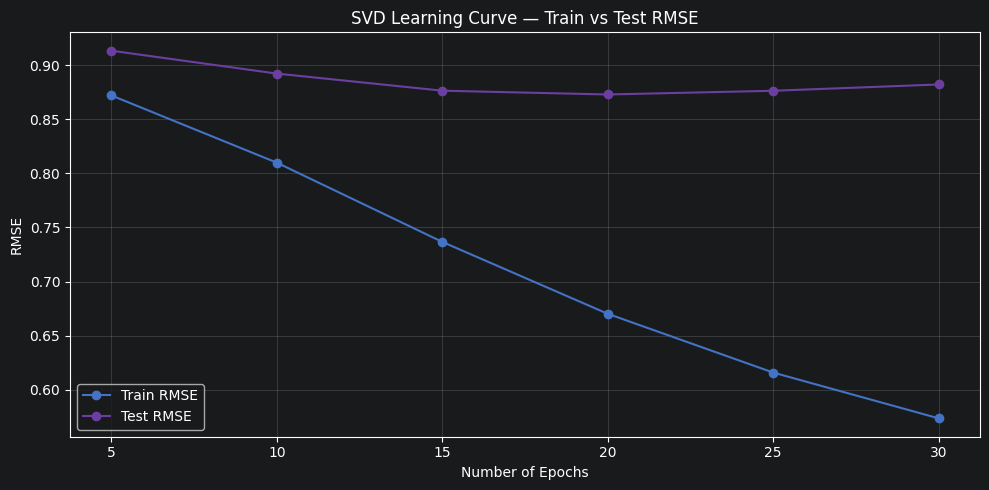

Learning curve saved → learning_curve.png


In [27]:
# OVERFITTING ANALYSIS
print("=== OVERFITTING ANALYSIS ===")

# SVD train vs test RMSE across different n_epochs
epochs_list = [5, 10, 15, 20, 25, 30]
train_rmses = []
test_rmses  = []

for n in epochs_list:
    model = SVD(n_factors=100, n_epochs=n, lr_all=0.005, reg_all=0.02, random_state=42)
    model.fit(trainset)

    # Test RMSE
    preds = model.test(testset)
    test_rmse = accuracy.rmse(preds, verbose=False)
    test_rmses.append(test_rmse)

    # Train RMSE
    train_preds = model.test(trainset.build_testset())
    train_rmse = accuracy.rmse(train_preds, verbose=False)
    train_rmses.append(train_rmse)

    print(f"Epochs {n:2d} → Train RMSE: {train_rmse:.4f} | Test RMSE: {test_rmse:.4f}")

# Learning curve plot
plt.figure(figsize=(10, 5))
plt.plot(epochs_list, train_rmses, marker="o", label="Train RMSE", color="#4472C4")
plt.plot(epochs_list, test_rmses,  marker="o", label="Test RMSE",  color="#6B3FA0")
plt.xlabel("Number of Epochs")
plt.ylabel("RMSE")
plt.title("SVD Learning Curve — Train vs Test RMSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150)
plt.show()
print("Learning curve saved → learning_curve.png")

In [28]:
# FINAL SUMMARY
print("=" * 60)
print("DELIVERY 3 — FINAL MODEL SUMMARY")
print("=" * 60)

print(f"\n{'Model':<22} {'RMSE':>8} {'MAE':>8} {'Notes'}")
print("-" * 60)
print(f"{'Baseline (User-CF)':<22} {0.9604:>8.4f} {0.7642:>8.4f}  Reference point")
print(f"{'SVD':<22} {svd_rmse:>8.4f} {svd_mae:>8.4f}  Best for experienced users")
print(f"{'Hybrid (SVD+CBF)':<22} {hybrid_rmse:>8.4f} {hybrid_mae:>8.4f}  Best overall — selected")

print(f"\nCold Start Simulation (< 25 ratings):")
print(f"  SVD    RMSE: 0.9684")
print(f"  Hybrid RMSE: 0.9011  (6.9% improvement)")

print(f"\nOverfitting: observed beyond epoch 20")
print(f"Regularization: reg_all=0.02 applied")
print(f"Optimal epochs: 20")

print(f"\nFinal Model Selected: Hybrid (SVD + CBF)")
print(f"Justification:")
print(f"  1. Best overall RMSE: 0.8696")
print(f"  2. Best cold start RMSE: 0.9011 (vs SVD 0.9684)")
print(f"  3. Maintains SVD-level performance for experienced users")
print(f"  4. Only model addressing both sparsity and cold start")
print("=" * 60)

DELIVERY 3 — FINAL MODEL SUMMARY

Model                      RMSE      MAE Notes
------------------------------------------------------------
Baseline (User-CF)       0.9604   0.7642  Reference point
SVD                      0.8729   0.6845  Best for experienced users
Hybrid (SVD+CBF)         0.8696   0.6822  Best overall — selected

Cold Start Simulation (< 25 ratings):
  SVD    RMSE: 0.9684
  Hybrid RMSE: 0.9011  (6.9% improvement)

Overfitting: observed beyond epoch 20
Regularization: reg_all=0.02 applied
Optimal epochs: 20

Final Model Selected: Hybrid (SVD + CBF)
Justification:
  1. Best overall RMSE: 0.8696
  2. Best cold start RMSE: 0.9011 (vs SVD 0.9684)
  3. Maintains SVD-level performance for experienced users
  4. Only model addressing both sparsity and cold start
